# Exploratory Data Analysis — SNF Incident Risk Model

**Context:** This notebook explores the anonymised clinical and operational data from a sample of skilled nursing facilities (SNFs) used to train an incident risk prediction model. The model predicts 30-day probability of three outcomes — **falls**, **unplanned return-to-hospital (RTH)**, and **wounds** — to help the insurer reduce claims exposure.

---
**Sections**
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Resident Demographics](#3)
4. [Target Variable Analysis & Class Imbalance](#4)
5. [Missing Values](#5)
6. [Vital Signs](#6)
7. [ADL Functional Status](#7)
8. [GG Mobility & Self-Care](#8)
9. [Comorbidities & Diagnoses](#9)
10. [Medications & Adherence](#10)
11. [Document Tags (NLP Signals)](#11)
12. [Temporal Patterns](#12)
13. [Facility-Level Heterogeneity](#13)
14. [Key Findings](#14)


In [ ]:
# Install dependencies
%pip install numpy pandas matplotlib seaborn pyarrow

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Add scripts/ to path so config and other modules can be imported
sys.path.insert(0, str(Path("scripts").resolve()))

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
})
PALETTE = ["#5B6ABD", "#C1453A", "#2A9D8F", "#F4A261", "#6D6875", "#264653"]
sns.set_palette(PALETTE)

# ── Path ───────────────────────────────────────────────────────────────────
from config import DATA_DIR

def load(table: str) -> pd.DataFrame:
    return pd.read_parquet(DATA_DIR / f"{table}.parquet")

print("Libraries loaded. Data directory:", DATA_DIR)
print("Available tables:", [p.stem for p in sorted(DATA_DIR.glob("*.parquet"))])

<a id="2"></a>
## 2. Dataset Overview

In [2]:
tables = [
    "residents","diagnoses","adl_responses","gg_responses","vitals",
    "medications","document_tags","lab_reports","incidents","injuries",
    "hospital_transfers","hospital_admissions","factors",
    "needs","care_plans","physician_orders","therapy_tracks",
]

rows = []
for t in tables:
    df = load(t)
    date_cols = [c for c in df.columns if any(k in c for k in ["_at","_date","date_"])]
    date_range = ""
    if date_cols:
        col = date_cols[0]
        try:
            s = pd.to_datetime(df[col], utc=False).dt.tz_localize(None)
            date_range = f"{s.min().date()} → {s.max().date()}"
        except Exception:
            pass
    rows.append({
        "Table": t, "Rows": f"{len(df):,}", "Columns": len(df.columns),
        "Date range": date_range,
    })

overview = pd.DataFrame(rows)
print(overview.to_string(index=False))


              Table      Rows  Columns              Date range
          residents     3,000        9 1919-11-12 → 2000-11-12
          diagnoses    60,620        8 1923-08-22 → 2029-09-23
      adl_responses   480,554       12 2024-04-26 → 2025-01-31
       gg_responses   660,711       10 2024-02-22 → 2025-01-31
             vitals 2,517,056        9 2023-07-01 → 2025-01-31
        medications 1,430,877        8 2023-08-14 → 2025-01-31
      document_tags   562,905        9 2023-07-13 → 2025-01-31
        lab_reports    13,334        9 2023-07-01 → 2025-01-31
          incidents     3,578        8 2019-01-10 → 2025-01-31
           injuries     1,219        7 2025-02-20 → 2026-02-23
 hospital_transfers     1,816       12 2006-09-13 → 2025-01-31
hospital_admissions     2,945        9 2005-02-23 → 2025-01-31
            factors   190,284        5 2019-01-10 → 2025-05-31
              needs   162,762       11 2005-02-23 → 2027-02-26
         care_plans     3,034        9 2010-03-15 → 202

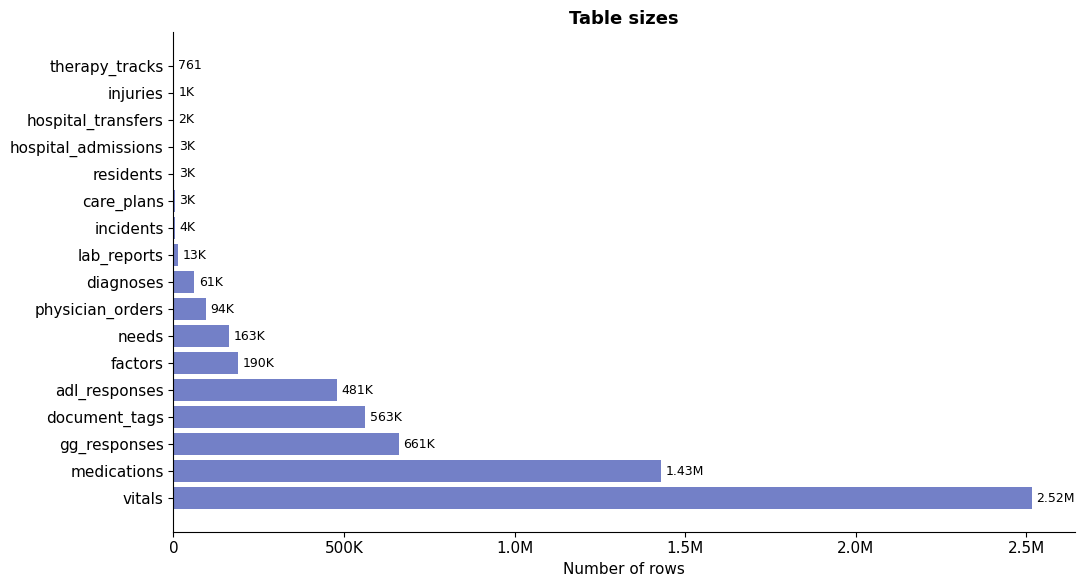


Key takeaway: vitals (2.5M), medications (1.4M), and GG/ADL responses dominate by volume — these drive the rolling feature computation.


In [3]:
# Table row counts as a horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 6))
counts = {r["Table"]: int(r["Rows"].replace(",","")) for r in rows}
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

bars = ax.barh(list(sorted_counts.keys()), list(sorted_counts.values()),
               color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Number of rows")
ax.set_title("Table sizes", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K" if x >= 1000 else str(int(x))))

for bar in bars:
    w = bar.get_width()
    label = f"{w/1e6:.2f}M" if w >= 1e6 else f"{w/1e3:.0f}K" if w >= 1000 else str(int(w))
    ax.text(w + ax.get_xlim()[1]*0.005, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey takeaway: vitals (2.5M), medications (1.4M), and GG/ADL responses "
      "dominate by volume — these drive the rolling feature computation.")


<a id="3"></a>
## 3. Resident Demographics

In [4]:
res = load("residents")
res["date_of_birth"]  = pd.to_datetime(res["date_of_birth"],  utc=False).dt.tz_localize(None)
res["admission_date"] = pd.to_datetime(res["admission_date"], utc=False).dt.tz_localize(None)
res["discharge_date"] = pd.to_datetime(res["discharge_date"], utc=False).dt.tz_localize(None)
res["deceased_date"]  = pd.to_datetime(res["deceased_date"],  utc=False).dt.tz_localize(None)

ref_date = pd.Timestamp("2024-01-01")
res["age"] = ((ref_date - res["date_of_birth"]).dt.days / 365.25)
res["los"] = ((res["discharge_date"].fillna(pd.Timestamp("2024-12-31")) - res["admission_date"]).dt.days).clip(0)

# Resident status
res["status"] = "Active"
res.loc[res["deceased_date"].notna(), "status"] = "Deceased"
res.loc[res["discharge_date"].notna() & res["deceased_date"].isna(), "status"] = "Discharged"

print(f"Total residents : {len(res):,}")
print(f"Facilities      : {res['facility_id'].nunique()}")
print(f"Residents/fac   : {res.groupby('facility_id').size().mean():.0f} (all equal = {res.groupby('facility_id').size().nunique()==1})")
print(f"\nResident status :")
print(res["status"].value_counts().to_string())
print(f"\nAge (ref 2024-01-01) :")
print(res["age"].describe().round(1).to_string())
print(f"\nLength of stay (days) :")
print(res["los"].describe().round(0).to_string())


Total residents : 3,000
Facilities      : 100
Residents/fac   : 30 (all equal = True)

Resident status :
status
Discharged    1881
Active         612
Deceased       507

Age (ref 2024-01-01) :
count    2998.0
mean       74.6
std        12.5
min        23.1
25%        66.5
50%        75.5
75%        83.7
max       104.1

Length of stay (days) :
count    3000.0
mean      305.0
std       602.0
min         0.0
25%        15.0
50%        47.0
75%       334.0
max      7250.0


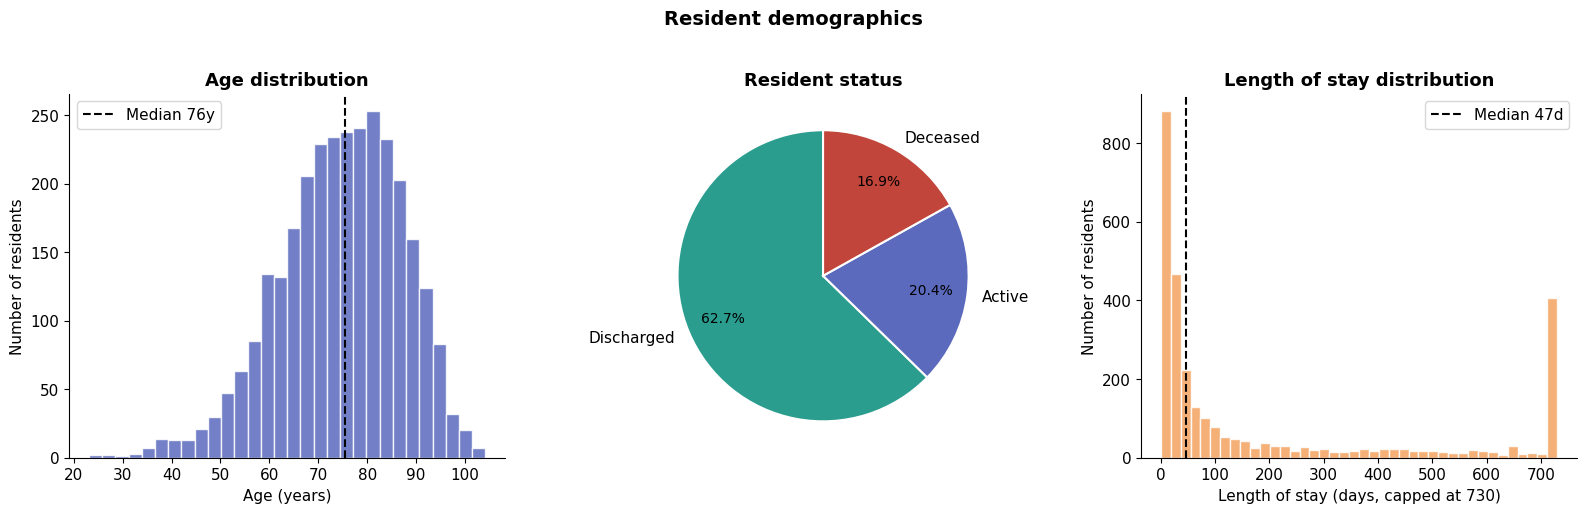


The bimodal LOS distribution reflects two distinct populations:
  Short-stay residents: post-acute rehabilitation (median ~30-60 days)
  Long-stay residents: chronic care (hundreds of days to years)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
ax = axes[0]
ax.hist(res["age"].dropna(), bins=30, color=PALETTE[0], alpha=0.85, edgecolor="white")
ax.axvline(res["age"].median(), color="black", lw=1.5, ls="--", label=f"Median {res['age'].median():.0f}y")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of residents")
ax.set_title("Age distribution", fontweight="bold")
ax.legend()

# Status pie
ax = axes[1]
status_counts = res["status"].value_counts()
wedge_colors = [PALETTE[2], PALETTE[0], PALETTE[1]]
wedges, texts, autotexts = ax.pie(
    status_counts, labels=status_counts.index,
    autopct="%1.1f%%", colors=wedge_colors,
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("Resident status", fontweight="bold")

# Length of stay distribution (log scale, clip at 730d)
ax = axes[2]
los_plot = res["los"].clip(0, 730)
ax.hist(los_plot, bins=40, color=PALETTE[3], alpha=0.85, edgecolor="white")
ax.axvline(res["los"].median(), color="black", lw=1.5, ls="--",
           label=f"Median {res['los'].median():.0f}d")
ax.set_xlabel("Length of stay (days, capped at 730)")
ax.set_ylabel("Number of residents")
ax.set_title("Length of stay distribution", fontweight="bold")
ax.legend()

plt.suptitle("Resident demographics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nThe bimodal LOS distribution reflects two distinct populations:")
print("  Short-stay residents: post-acute rehabilitation (median ~30-60 days)")
print("  Long-stay residents: chronic care (hundreds of days to years)")


<a id="4"></a>
## 4. Target Variable Analysis & Class Imbalance

Understanding incident prevalence is critical for two reasons: it sets the baseline for the insurer's expected loss, and it determines the severity of class imbalance the model must handle.

In [6]:
inc = load("incidents")
inc = inc[inc["strikeout"] == False]
inc["occurred_at"] = pd.to_datetime(inc["occurred_at"], utc=False).dt.tz_localize(None)

print("=== Overall incident distribution ===")
type_counts = inc["incident_type"].value_counts()
print(type_counts.to_string())
print(f"\nTotal incidents       : {len(inc):,}")
print(f"Residents affected    : {inc['resident_id'].nunique():,} / {len(res):,} = "
      f"{inc['resident_id'].nunique()/len(res):.1%}")


=== Overall incident distribution ===
incident_type
Fall                2505
Wound                589
Altercation          228
Medication Error      44
Choking                9
Elopement              7

Total incidents       : 3,382
Residents affected    : 978 / 3,000 = 32.6%


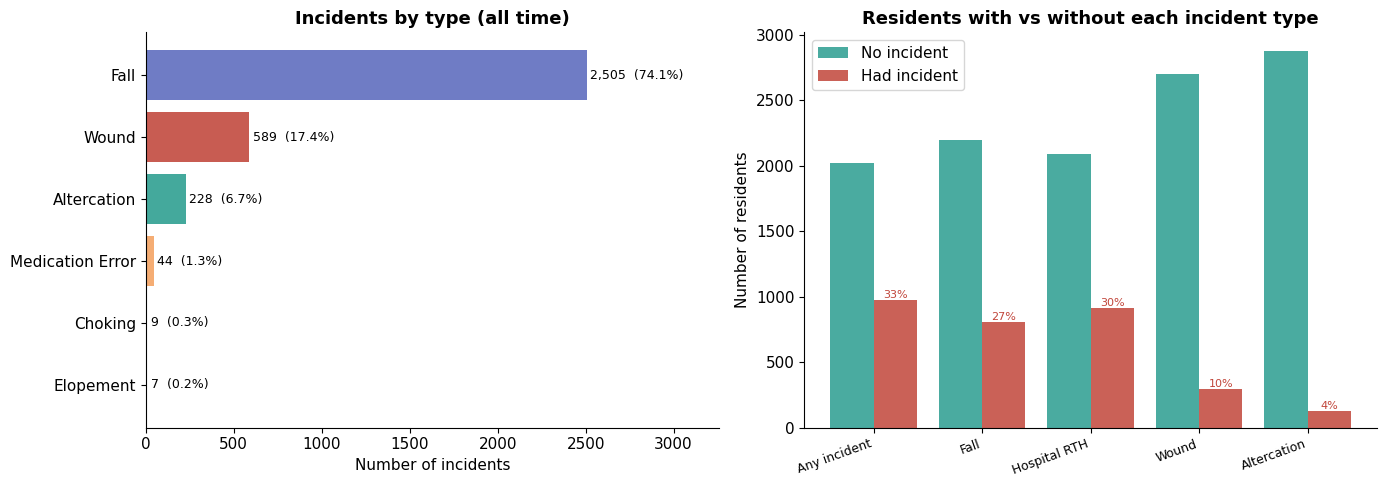

Falls account for 70%+ of all incidents, but RTH is modeled separately
because its $20K avg cost makes it the top dollar driver despite fewer events.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Incident type breakdown
ax = axes[0]
type_counts = inc["incident_type"].value_counts()
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1],
               color=PALETTE[:len(type_counts)][::-1], alpha=0.88)
ax.set_xlabel("Number of incidents")
ax.set_title("Incidents by type (all time)", fontweight="bold")
for bar in bars:
    w = bar.get_width()
    pct = w / type_counts.sum()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2,
            f"{w:,}  ({pct:.1%})", va="center", fontsize=9)
ax.set_xlim(0, type_counts.max() * 1.3)

# Right: Residents with/without each major incident type
ax = axes[1]
categories = {
    "Any incident":   inc["resident_id"].nunique(),
    "Fall":           inc[inc["incident_type"]=="Fall"]["resident_id"].nunique(),
    "Hospital RTH":   load("hospital_transfers")["resident_id"].nunique(),
    "Wound":          inc[inc["incident_type"]=="Wound"]["resident_id"].nunique(),
    "Altercation":    inc[inc["incident_type"]=="Altercation"]["resident_id"].nunique(),
}

n_res = len(res)
names  = list(categories.keys())
with_  = list(categories.values())
without = [n_res - w for w in with_]

x = np.arange(len(names))
w = 0.4
bars1 = ax.bar(x - w/2, without, w, label="No incident", color=PALETTE[2], alpha=0.85)
bars2 = ax.bar(x + w/2, with_,   w, label="Had incident", color=PALETTE[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Number of residents")
ax.set_title("Residents with vs without each incident type", fontweight="bold")
ax.legend()

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 15, f"{h/n_res:.0%}",
            ha="center", fontsize=8, color=PALETTE[1])

plt.tight_layout()
plt.show()

print("Falls account for 70%+ of all incidents, but RTH is modeled separately")
print("because its $20K avg cost makes it the top dollar driver despite fewer events.")


=== Fall frequency per resident ===
Residents with exactly 1 fall : 384
Repeat fallers (2+)           : 422
High-frequency fallers (5+)   : 140
Max falls by one resident     : 42
Mean falls (among fallers)    : 3.11


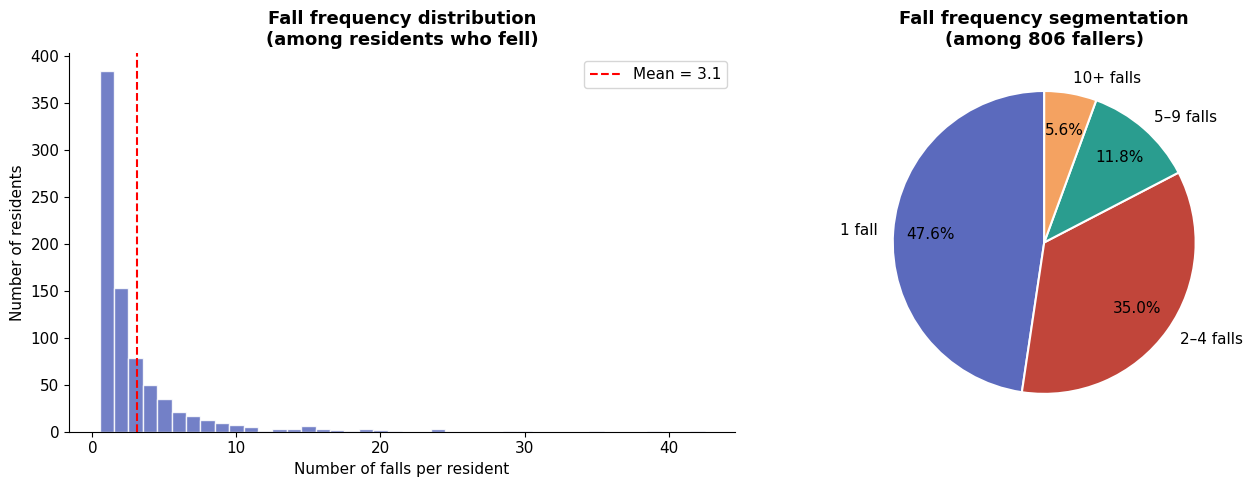


Repeat fallers are a concentrated risk segment: 52% of fallers fall 2+ times.
Identifying them early allows targeted intervention (PT, environmental modification).


In [8]:
# ── Repeat faller analysis ────────────────────────────────────────────────
falls = inc[inc["incident_type"] == "Fall"]
fall_counts = falls.groupby("resident_id").size()

print("=== Fall frequency per resident ===")
print(f"Residents with exactly 1 fall : {(fall_counts==1).sum()}")
print(f"Repeat fallers (2+)           : {(fall_counts>=2).sum()}")
print(f"High-frequency fallers (5+)   : {(fall_counts>=5).sum()}")
print(f"Max falls by one resident     : {fall_counts.max()}")
print(f"Mean falls (among fallers)    : {fall_counts.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fall count distribution
ax = axes[0]
ax.hist(fall_counts.values, bins=range(1, fall_counts.max()+2),
        color=PALETTE[0], alpha=0.85, edgecolor="white", align="left")
ax.axvline(fall_counts.mean(), color="red", lw=1.5, ls="--",
           label=f"Mean = {fall_counts.mean():.1f}")
ax.set_xlabel("Number of falls per resident")
ax.set_ylabel("Number of residents")
ax.set_title("Fall frequency distribution\n(among residents who fell)", fontweight="bold")
ax.legend()

# Falls vs non-falls residents as proportion
ax = axes[1]
labels = ["1 fall", "2–4 falls", "5–9 falls", "10+ falls"]
counts_grouped = [
    (fall_counts==1).sum(),
    ((fall_counts>=2) & (fall_counts<=4)).sum(),
    ((fall_counts>=5) & (fall_counts<=9)).sum(),
    (fall_counts>=10).sum(),
]
colors_pie = [PALETTE[i] for i in range(4)]
wedges, texts, autotexts = ax.pie(
    counts_grouped, labels=labels, autopct="%1.1f%%",
    colors=colors_pie, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.75,
)
ax.set_title("Fall frequency segmentation\n(among 806 fallers)", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nRepeat fallers are a concentrated risk segment: 52% of fallers fall 2+ times.")
print("Identifying them early allows targeted intervention (PT, environmental modification).")


=== RTH (hospital transfers) ===
Total transfers   : 1,816
Unplanned         : 1,770  (97.5%)
Unplanned+admitted: 917  (50.5%)
Residents affected: 911 / 3,000

Top transfer reasons:
transfer_reason
Other                                                        474
Altered Mental Status                                        128
Fall                                                         127
Shortness of Breath (bronchitis, pneumonia)                   87
Chest Pain                                                    57
Abnormal Vital Signs (low/high BP, high respiratory rate)     53
Behavioral symptoms (e.g. agitation, psychosis)               47
Abdominal pain                                                42
Abnormal Hemoglobin or Hematocrit (low)                       40
Pain (uncontrolled)                                           35


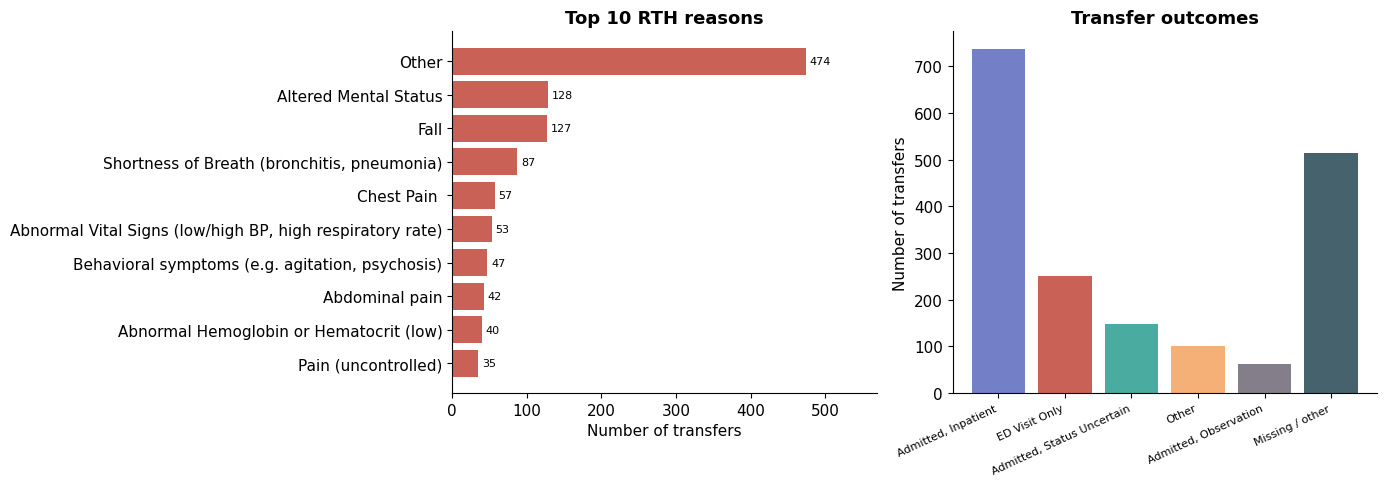


Fall is the 2nd leading transfer reason — RTH and fall risk are correlated,
justifying shared features across both prediction targets.


In [9]:
# ── RTH analysis ─────────────────────────────────────────────────────────
xfer = load("hospital_transfers")
xfer["effective_date"] = pd.to_datetime(xfer["effective_date"], utc=False).dt.tz_localize(None)

unplanned = xfer[xfer["planned_flag"].fillna(False) == False]
admitted  = unplanned[unplanned["transfer_outcome"].fillna("").str.contains("Admitted", na=False)]

print("=== RTH (hospital transfers) ===")
print(f"Total transfers   : {len(xfer):,}")
print(f"Unplanned         : {len(unplanned):,}  ({len(unplanned)/len(xfer):.1%})")
print(f"Unplanned+admitted: {len(admitted):,}  ({len(admitted)/len(xfer):.1%})")
print(f"Residents affected: {xfer['resident_id'].nunique():,} / {len(res):,}")
print(f"\nTop transfer reasons:")
print(xfer["transfer_reason"].value_counts().head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reason breakdown
ax = axes[0]
top_reasons = xfer["transfer_reason"].value_counts().head(10)
ax.barh(top_reasons.index[::-1], top_reasons.values[::-1],
        color=PALETTE[1], alpha=0.85)
ax.set_xlabel("Number of transfers")
ax.set_title("Top 10 RTH reasons", fontweight="bold")
ax.set_xlim(0, top_reasons.max() * 1.2)
for i, (v, n) in enumerate(zip(top_reasons.values[::-1], top_reasons.index[::-1])):
    ax.text(v + 5, i, str(v), va="center", fontsize=8)

# Outcome breakdown
ax = axes[1]
outcome_counts = xfer["transfer_outcome"].value_counts().head(6)
outcome_counts["Missing / other"] = len(xfer) - outcome_counts.sum()
ax.bar(range(len(outcome_counts)), outcome_counts.values,
       color=[PALETTE[i % len(PALETTE)] for i in range(len(outcome_counts))], alpha=0.85)
ax.set_xticks(range(len(outcome_counts)))
ax.set_xticklabels(outcome_counts.index, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Number of transfers")
ax.set_title("Transfer outcomes", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nFall is the 2nd leading transfer reason — RTH and fall risk are correlated,")
print("justifying shared features across both prediction targets.")


=== Class imbalance (approximated at resident level) ===

Note: the model uses (resident × week) rows with a 30-day label window.
Positive rates at row level will be lower than resident-level rates below.



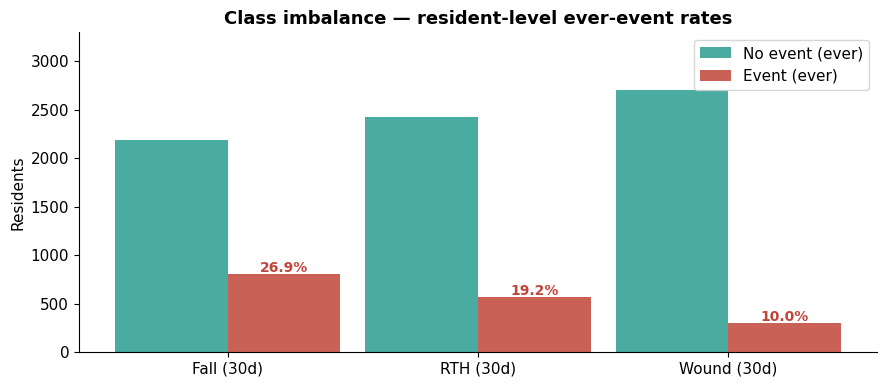


Resident-level positive rates:
  fall_30d    :  806 / 3000 = 26.9%
  rth_30d     :  575 / 3000 = 19.2%
  wound_30d   :  299 / 3000 = 10.0%

At the (resident × week) observation level, the 30-day window positive
rate is substantially lower (~3-8%), driving the need for scale_pos_weight.


In [10]:
# ── Class imbalance quantification ────────────────────────────────────────
print("=== Class imbalance (approximated at resident level) ===")
print("\nNote: the model uses (resident × week) rows with a 30-day label window.")
print("Positive rates at row level will be lower than resident-level rates below.")
print()

total = len(res)
resident_ids = set(res["resident_id"])

targets = {
    "fall_30d"  : inc[inc["incident_type"]=="Fall"]["resident_id"].nunique(),
    "rth_30d"   : admitted["resident_id"].nunique(),
    "wound_30d" : inc[inc["incident_type"]=="Wound"]["resident_id"].nunique(),
}

fig, ax = plt.subplots(figsize=(9, 4))
names  = list(targets.keys())
pos    = list(targets.values())
neg    = [total - p for p in pos]
rates  = [p/total for p in pos]

x = np.arange(len(names))
w = 0.45
ax.bar(x - w/2, neg, w, label="No event (ever)", color=PALETTE[2], alpha=0.85)
ax.bar(x + w/2, pos, w, label="Event (ever)",    color=PALETTE[1], alpha=0.85)

for i, (p, r) in enumerate(zip(pos, rates)):
    ax.text(i + w/2, p + 20, f"{r:.1%}", ha="center", fontsize=10,
            color=PALETTE[1], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Fall (30d)", "RTH (30d)", "Wound (30d)"], fontsize=11)
ax.set_ylabel("Residents")
ax.set_title("Class imbalance — resident-level ever-event rates", fontweight="bold")
ax.legend()
ax.set_ylim(0, total * 1.1)
plt.tight_layout()
plt.show()

print("\nResident-level positive rates:")
for name, (k, v) in zip(names, targets.items()):
    print(f"  {k:12s}: {v:4d} / {total} = {v/total:.1%}")
print()
print("At the (resident × week) observation level, the 30-day window positive")
print("rate is substantially lower (~3-8%), driving the need for scale_pos_weight.")


<a id="5"></a>
## 5. Missing Values

Missingness is an important modeling consideration. XGBoost handles it natively by learning optimal default directions for missing values during training — but the *pattern* of missingness is itself informative.

In [11]:
# Build missing value summary across all tables
null_summary = []
for t in tables:
    df = load(t)
    for col in df.columns:
        n_null = df[col].isnull().sum()
        if n_null > 0:
            null_summary.append({
                "table": t, "column": col,
                "n_null": n_null, "pct_null": n_null / len(df),
                "n_rows": len(df),
            })

null_df = pd.DataFrame(null_summary).sort_values("pct_null", ascending=False)
print("Columns with missing values:")
print(null_df[["table","column","n_null","pct_null"]].to_string(index=False))


Columns with missing values:
              table                 column  n_null  pct_null
hospital_admissions         emergency_flag    2945  1.000000
      document_tags             deleted_at  562840  0.999885
   physician_orders              frequency   93337  0.992408
          diagnoses            resolved_at   52988  0.874101
             vitals         dystolic_value 2146394  0.852740
          residents          deceased_date    2493  0.831000
              needs            resolved_at  129495  0.795610
   physician_orders                 end_at   68643  0.729849
hospital_admissions       hospital_stay_to    1478  0.501868
       gg_responses                 change  313394  0.474328
         care_plans          closed_reason    1116  0.367831
         care_plans              closed_at    1116  0.367831
 hospital_transfers       transfer_outcome     515  0.283590
      document_tags       match_confidence  127822  0.227076
      document_tags               editable  127427  0.22

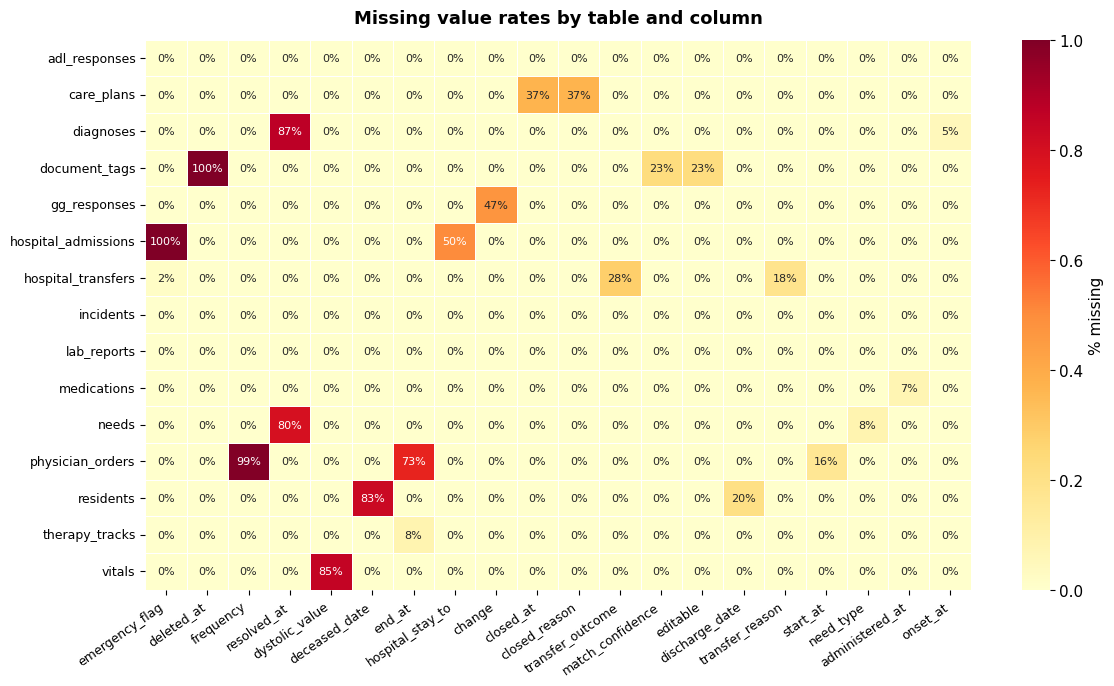


Key observations:
  diagnoses.resolved_at   87% null → most diagnoses are chronic (expected for SNF)
  residents.deceased_date 83% null → correct: most residents are alive or discharged
  vitals.dystolic_value   85% null → column only populated for BP readings
  hospital_transfers.transfer_outcome 28% null → important label; imputed in target def
  medications.administered_at 7% null → aligns exactly with the 7% missed-dose rate


In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

pivot = null_df.pivot_table(index="table", columns="column", values="pct_null", aggfunc="first").fillna(0)
# Only show columns with any non-zero missingness
pivot = pivot.loc[:, (pivot > 0).any()]
# Limit to most interesting columns
top_cols = null_df.groupby("column")["pct_null"].max().nlargest(20).index
pivot_top = pivot[[c for c in top_cols if c in pivot.columns]]

sns.heatmap(pivot_top, annot=True, fmt=".0%", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, cbar_kws={"label": "% missing"},
            ax=ax)
ax.set_title("Missing value rates by table and column", fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  diagnoses.resolved_at   87% null → most diagnoses are chronic (expected for SNF)")
print("  residents.deceased_date 83% null → correct: most residents are alive or discharged")
print("  vitals.dystolic_value   85% null → column only populated for BP readings")
print("  hospital_transfers.transfer_outcome 28% null → important label; imputed in target def")
print("  medications.administered_at 7% null → aligns exactly with the 7% missed-dose rate")


<a id="6"></a>
## 6. Vital Signs

Vitals are the largest table (2.5M rows) and carry the richest time-series signal. Rolling statistics at 7, 30, and 90-day windows — mean, standard deviation, min, max — are computed per vital type and used as model features.

In [13]:
vit = load("vitals")
vit = vit[vit["strikeout"] == False]
vit["measured_at"] = pd.to_datetime(vit["measured_at"], utc=False).dt.tz_localize(None)

print(f"Total valid vital readings : {len(vit):,}")
print(f"Date range                 : {vit['measured_at'].min().date()} → {vit['measured_at'].max().date()}")
print(f"\nReadings per vital type:")
print(vit["vital_type"].value_counts().to_string())
print(f"\nReadings per resident (avg): {len(vit)/res['resident_id'].nunique():.0f}")


Total valid vital readings : 2,512,667
Date range                 : 2023-07-01 → 2025-01-31

Readings per vital type:
vital_type
Pain Level       830599
BP - Systolic    370019
Pulse            335722
O2 sats          266527
Blood Sugar      250258
Temperature      237982
Respiration      189043
Weight            32517

Readings per resident (avg): 838


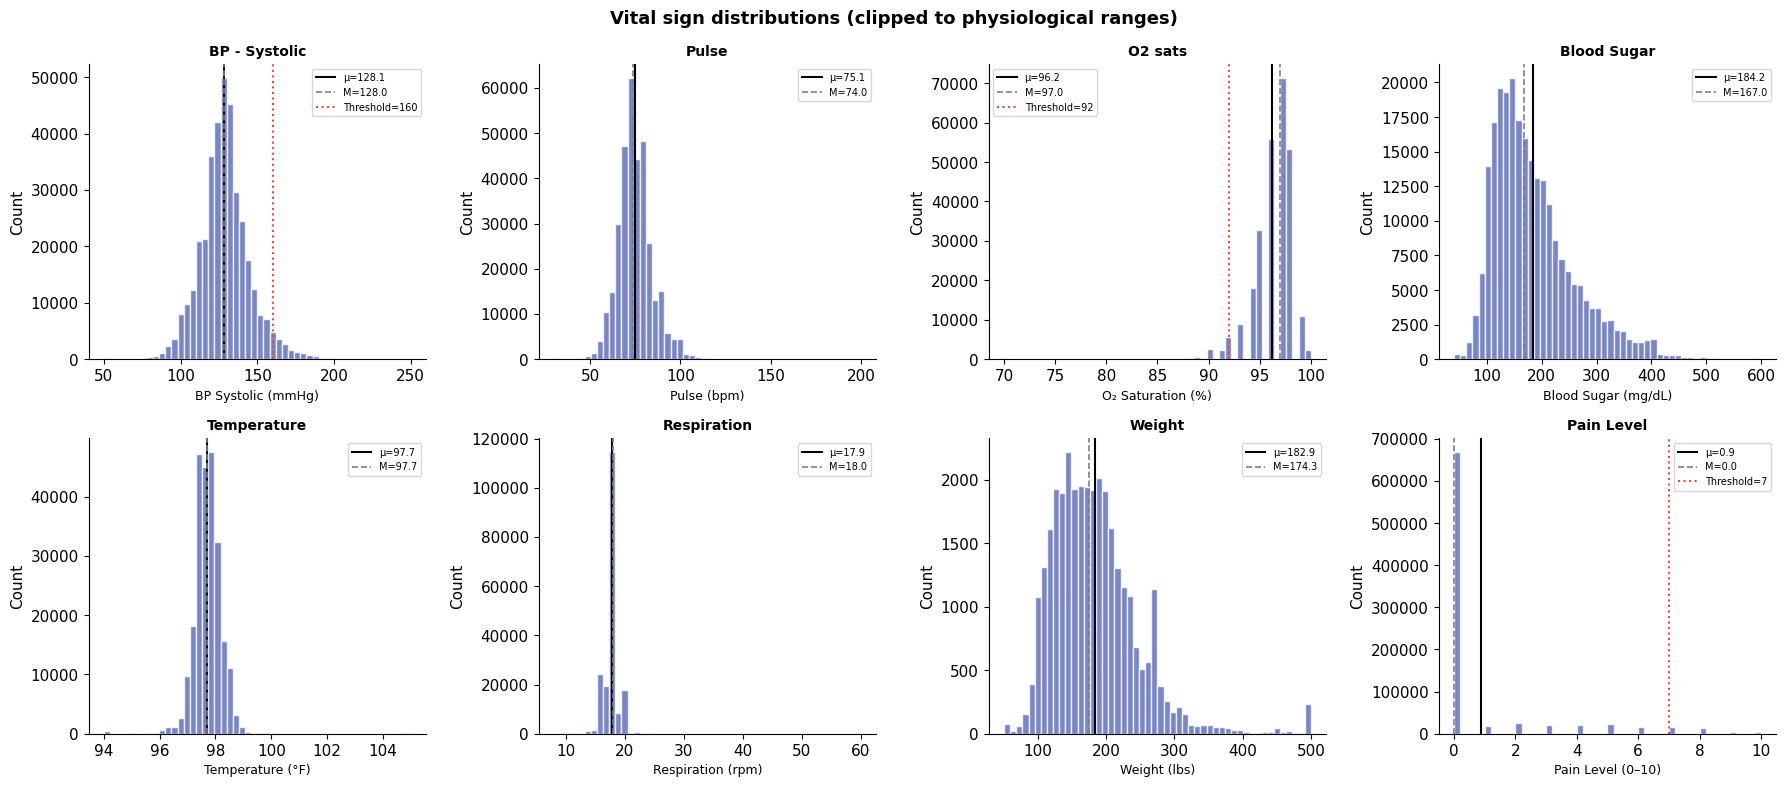

In [14]:
VITAL_COL = {
    "BP - Systolic": "BP Systolic (mmHg)",
    "Pulse": "Pulse (bpm)",
    "O2 sats": "O₂ Saturation (%)",
    "Blood Sugar": "Blood Sugar (mg/dL)",
    "Temperature": "Temperature (°F)",
    "Respiration": "Respiration (rpm)",
    "Weight": "Weight (lbs)",
    "Pain Level": "Pain Level (0–10)",
}
VITAL_CLIP = {
    "BP - Systolic": (50, 250), "Pulse": (30, 200),
    "O2 sats": (70, 100), "Blood Sugar": (40, 600),
    "Temperature": (94, 105), "Respiration": (8, 60),
    "Weight": (50, 500), "Pain Level": (0, 10),
}
VITAL_FLAGS = {
    "O2 sats": (92, "low", "#e74c3c"),
    "BP - Systolic": (160, "high", "#e74c3c"),
    "Pain Level": (7, "high", "#e74c3c"),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (vtype, label) in zip(axes, VITAL_COL.items()):
    lo, hi = VITAL_CLIP[vtype]
    vals = vit[vit["vital_type"] == vtype]["value"].clip(lo, hi).dropna()
    ax.hist(vals, bins=50, color=PALETTE[0], alpha=0.82, edgecolor="white")
    ax.axvline(vals.mean(),   color="black", lw=1.5, ls="-",  label=f"μ={vals.mean():.1f}")
    ax.axvline(vals.median(), color="gray",  lw=1.2, ls="--", label=f"M={vals.median():.1f}")
    if vtype in VITAL_FLAGS:
        thr, direction, color = VITAL_FLAGS[vtype]
        ax.axvline(thr, color=color, lw=1.5, ls=":", label=f"Threshold={thr}")
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("Count")
    ax.set_title(vtype, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)

plt.suptitle("Vital sign distributions (clipped to physiological ranges)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


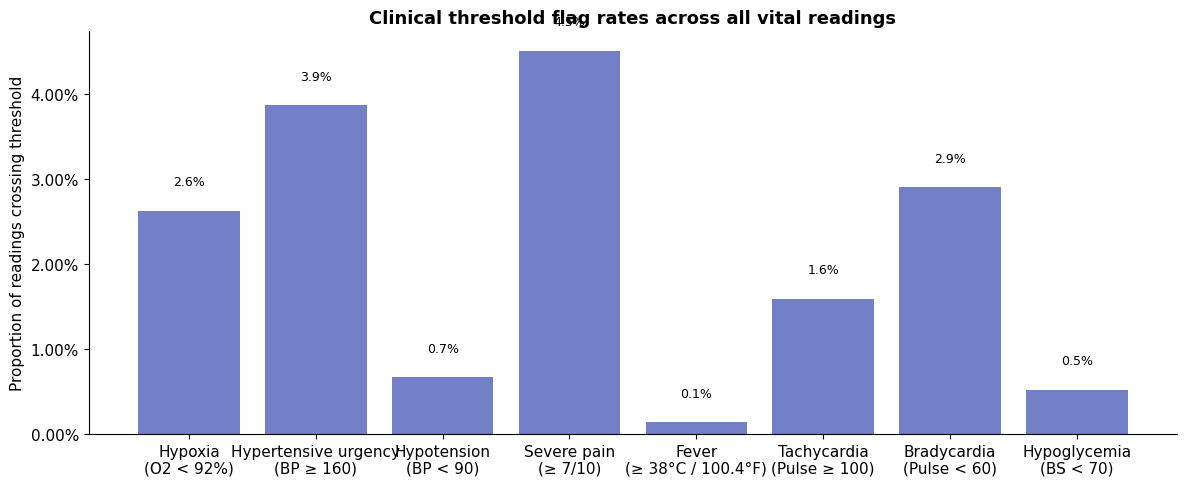


BP variability (coefficient of variation) is a key derived feature —
unstable BP is a stronger fall and RTH predictor than mean BP level.


In [15]:
# ── Clinical flag prevalence ───────────────────────────────────────────────
thresholds = {
    "Hypoxia\n(O2 < 92%)":        ("O2 sats",       lambda v: v < 92),
    "Hypertensive urgency\n(BP ≥ 160)": ("BP - Systolic", lambda v: v >= 160),
    "Hypotension\n(BP < 90)":      ("BP - Systolic", lambda v: v < 90),
    "Severe pain\n(≥ 7/10)":       ("Pain Level",    lambda v: v >= 7),
    "Fever\n(≥ 38°C / 100.4°F)":  ("Temperature",   lambda v: v >= 100.4),
    "Tachycardia\n(Pulse ≥ 100)":  ("Pulse",         lambda v: v >= 100),
    "Bradycardia\n(Pulse < 60)":   ("Pulse",         lambda v: v < 60),
    "Hypoglycemia\n(BS < 70)":     ("Blood Sugar",   lambda v: v < 70),
}

flag_rates = {}
for flag_name, (vtype, condition) in thresholds.items():
    sub = vit[vit["vital_type"] == vtype]["value"]
    flag_rates[flag_name] = condition(sub).mean()

fig, ax = plt.subplots(figsize=(12, 5))
names = list(flag_rates.keys())
rates = list(flag_rates.values())
colors = [PALETTE[1] if r > 0.05 else PALETTE[0] for r in rates]
bars = ax.bar(names, rates, color=colors, alpha=0.85)
ax.set_ylabel("Proportion of readings crossing threshold")
ax.set_title("Clinical threshold flag rates across all vital readings", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{r:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nBP variability (coefficient of variation) is a key derived feature —")
print("unstable BP is a stronger fall and RTH predictor than mean BP level.")


<a id="7"></a>
## 7. ADL Functional Status

Activities of Daily Living (ADL) self-performance is scored 0 (independent) to 4 (total dependence). Trends in these scores — especially rapid decline — are among the strongest predictors of falls and RTH events.

In [16]:
adl = load("adl_responses")
adl_sp = adl[adl["category"] == "Self-Performance"].copy()
adl_sp["response_num"] = pd.to_numeric(adl_sp["response"], errors="coerce")
adl_sp = adl_sp[adl_sp["response_num"].between(0, 4)]
adl_sp["assessment_date"] = pd.to_datetime(adl_sp["assessment_date"], utc=False).dt.tz_localize(None)

print(f"ADL self-performance rows (scored 0-4): {len(adl_sp):,}")
print(f"Residents with ADL data: {adl_sp['resident_id'].nunique():,}")
print(f"\nADL score distribution (all activities):")
print(adl_sp["response_num"].value_counts().sort_index().to_string())
print(f"\nADL score label mapping: 0=Independent  1=Supervision  2=Limited assist  "
      f"3=Extensive assist  4=Total dependence")
print(f"\nMean ADL score by activity (higher = more dependent):")
print(adl_sp.groupby("activity")["response_num"].mean().sort_values(ascending=False).round(2).to_string())


ADL self-performance rows (scored 0-4): 175,389
Residents with ADL data: 96

ADL score distribution (all activities):
response_num
0.0    68191
1.0    10664
2.0    19312
3.0    23947
4.0    53275

ADL score label mapping: 0=Independent  1=Supervision  2=Limited assist  3=Extensive assist  4=Total dependence

Mean ADL score by activity (higher = more dependent):
activity
Bathing - Self-Performance                3.15
Dressing - Self-Performance               2.48
Personal hygiene - Self-Performance       2.42
Toilet use - Self-Performance             2.18
Bed mobility - Self-Performance           2.06
Transfer - Self-Performance               1.73
Locomotion on unit - Self-Performance     1.73
Locomotion off unit - Self-Performance    1.69
Eating - Self-Performance                 1.14
Walk in corridor - Self-Performance       1.03
Walk in room - Self-Performance           0.98


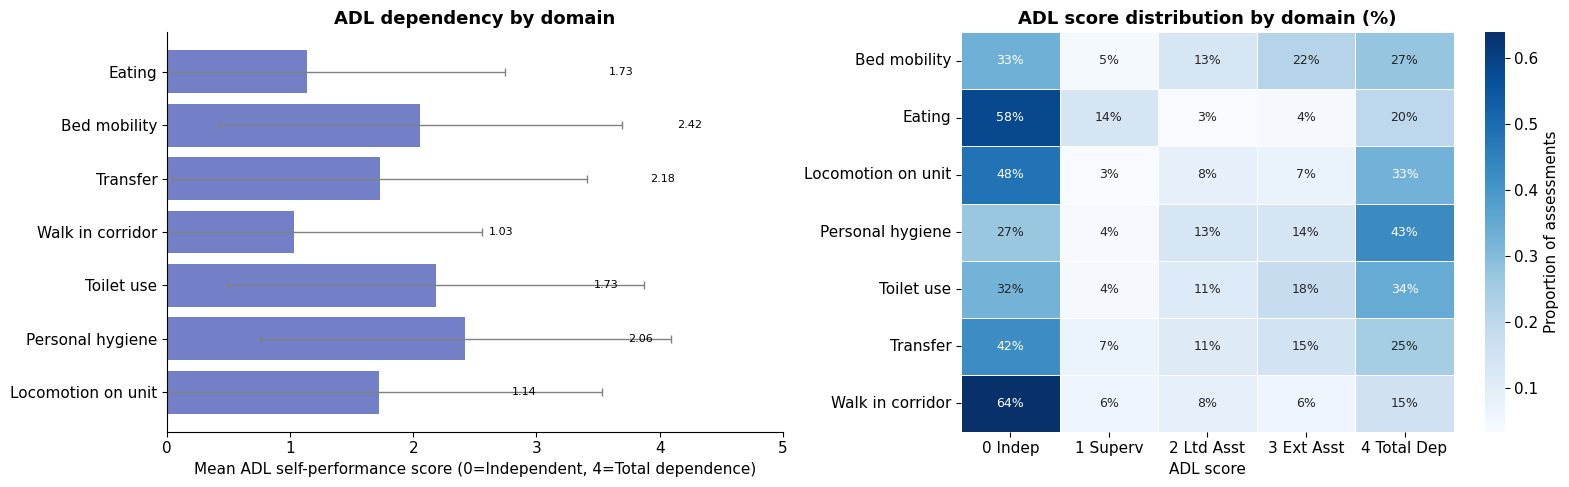


Bathing and dressing show the highest dependency — expected in SNF populations.
Walking and eating show more independence, making any decline highly predictive.


In [17]:
ADL_ACTIVITIES = [
    "Eating - Self-Performance",
    "Bed mobility - Self-Performance",
    "Transfer - Self-Performance",
    "Walk in corridor - Self-Performance",
    "Toilet use - Self-Performance",
    "Personal hygiene - Self-Performance",
    "Locomotion on unit - Self-Performance",
]
ACT_SHORT = {a: a.split(" - ")[0] for a in ADL_ACTIVITIES}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean ADL score per activity with std band
ax = axes[0]
act_stats = (adl_sp[adl_sp["activity"].isin(ADL_ACTIVITIES)]
             .groupby("activity")["response_num"]
             .agg(["mean","std"])
             .loc[ADL_ACTIVITIES]
             .rename(index=ACT_SHORT))
bars = ax.barh(act_stats.index[::-1], act_stats["mean"][::-1],
               xerr=act_stats["std"][::-1], color=PALETTE[0], alpha=0.85,
               error_kw={"elinewidth": 1, "capsize": 3, "ecolor": "gray"})
ax.set_xlabel("Mean ADL self-performance score (0=Independent, 4=Total dependence)")
ax.set_title("ADL dependency by domain", fontweight="bold")
ax.set_xlim(0, 5)
for bar, (act, row) in zip(bars[::-1], act_stats[::-1].iterrows()):
    ax.text(row["mean"] + row["std"] + 0.05, bar.get_y() + bar.get_height()/2,
            f"{row['mean']:.2f}", va="center", fontsize=8)

# Right: score distribution heatmap
ax = axes[1]
sub_acts = adl_sp[adl_sp["activity"].isin(ADL_ACTIVITIES)].copy()
sub_acts["act_short"] = sub_acts["activity"].map(ACT_SHORT)
piv = (sub_acts.groupby(["act_short","response_num"])
       .size()
       .unstack(fill_value=0)
       .apply(lambda r: r/r.sum(), axis=1))
piv.columns = ["0 Indep", "1 Superv", "2 Ltd Asst", "3 Ext Asst", "4 Total Dep"]

sns.heatmap(piv, annot=True, fmt=".0%", cmap="Blues",
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9}, cbar_kws={"label": "Proportion of assessments"},
            ax=ax)
ax.set_title("ADL score distribution by domain (%)", fontweight="bold")
ax.set_xlabel("ADL score")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

print("\nBathing and dressing show the highest dependency — expected in SNF populations.")
print("Walking and eating show more independence, making any decline highly predictive.")


<a id="8"></a>
## 8. GG Mobility & Self-Care

CMS Section GG assessments are clinically audited because they tie directly to Medicare PDPM reimbursement, making them more reliably coded than ADL. The scale runs 1 (dependent) to 6 (independent). We invert to a dependency score (7 − response_code) so higher always means more dependent.

In [18]:
gg = load("gg_responses")
gg_valid = gg[gg["response_code"].between(1, 6)].copy()
gg_valid["dependency"] = 7.0 - gg_valid["response_code"]
gg_valid["created_at"] = pd.to_datetime(gg_valid["created_at"], utc=False).dt.tz_localize(None)

print(f"GG rows (valid codes 1-6): {len(gg_valid):,} / {len(gg):,} total")
print(f"Filtered out (code 9=not applicable, 88=not attempted): "
      f"{len(gg)-len(gg_valid):,} ({(len(gg)-len(gg_valid))/len(gg):.1%})")
print(f"\nTask groups:")
print(gg_valid["task_group"].value_counts().to_string())
print(f"\nDependency score distribution (0=independent, 5=fully dependent):")
print(gg_valid["dependency"].value_counts().sort_index().to_string())


GG rows (valid codes 1-6): 455,964 / 660,711 total
Filtered out (code 9=not applicable, 88=not attempted): 204,747 (31.0%)

Task groups:
task_group
Mobility     238045
Self Care    217919

Dependency score distribution (0=independent, 5=fully dependent):
dependency
1.0    124157
2.0     60818
3.0     56023
4.0     39137
5.0     51363
6.0    124466


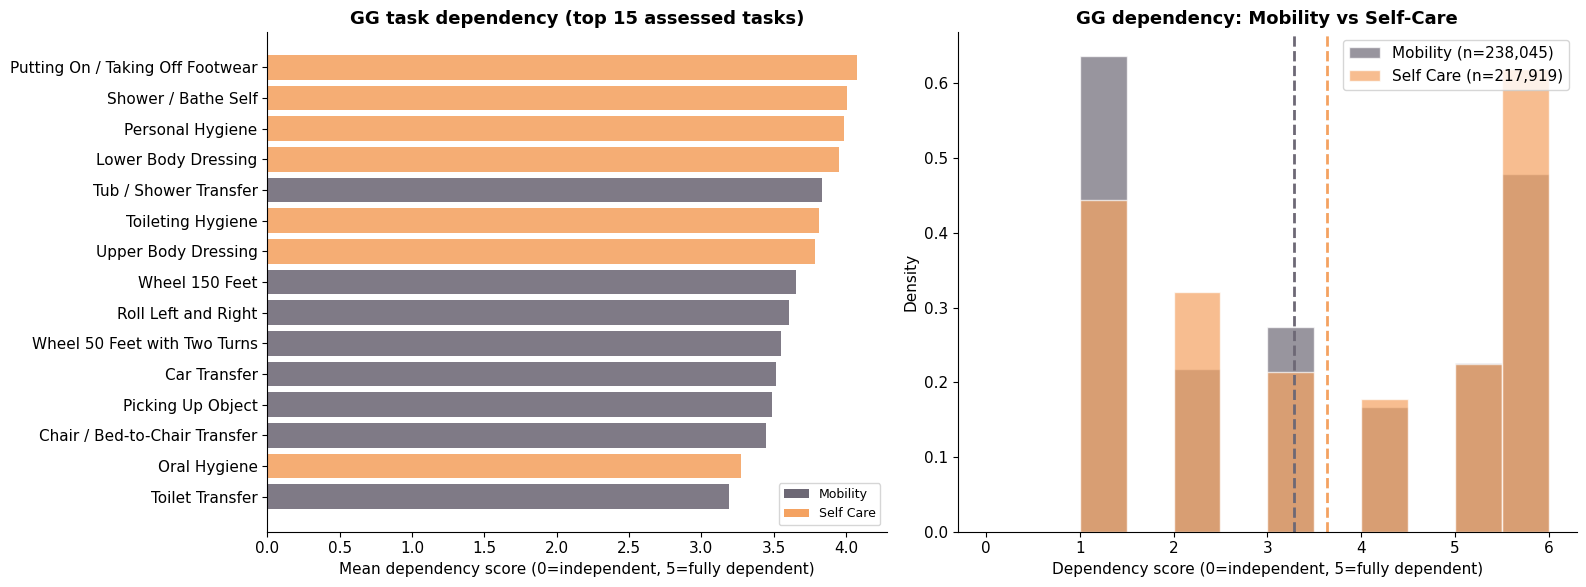


Mobility mean dependency : 3.28
Self-Care mean dependency : 3.64

Sit-to-Stand and Chair Transfer are the strongest GG predictors of falls.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: mean dependency by task
top_tasks = (gg_valid.groupby("task_name")["dependency"]
             .agg(["mean","count"])
             .query("count >= 500")
             .sort_values("mean", ascending=False)
             .head(15))

ax = axes[0]
colors_g = [PALETTE[4] if "Mobility" in gg_valid[gg_valid["task_name"]==t]["task_group"].iloc[0]
            else PALETTE[3] for t in top_tasks.index]
ax.barh(top_tasks.index[::-1], top_tasks["mean"][::-1],
        color=colors_g[::-1], alpha=0.88)
ax.set_xlabel("Mean dependency score (0=independent, 5=fully dependent)")
ax.set_title("GG task dependency (top 15 assessed tasks)", fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=PALETTE[4], label="Mobility"),
                Patch(facecolor=PALETTE[3], label="Self Care")]
ax.legend(handles=legend_elems, fontsize=9)

# Right: Mobility vs Self-Care distributions
ax = axes[1]
mob_dep = gg_valid[gg_valid["task_group"]=="Mobility"]["dependency"]
sc_dep  = gg_valid[gg_valid["task_group"]=="Self Care"]["dependency"]

bins = np.arange(0, 6.5, 0.5)
ax.hist(mob_dep, bins=bins, alpha=0.7, color=PALETTE[4], label=f"Mobility (n={len(mob_dep):,})",
        density=True, edgecolor="white")
ax.hist(sc_dep,  bins=bins, alpha=0.7, color=PALETTE[3], label=f"Self Care (n={len(sc_dep):,})",
        density=True, edgecolor="white")
ax.axvline(mob_dep.mean(), color=PALETTE[4], lw=2, ls="--")
ax.axvline(sc_dep.mean(),  color=PALETTE[3], lw=2, ls="--")
ax.set_xlabel("Dependency score (0=independent, 5=fully dependent)")
ax.set_ylabel("Density")
ax.set_title("GG dependency: Mobility vs Self-Care", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMobility mean dependency : {mob_dep.mean():.2f}")
print(f"Self-Care mean dependency : {sc_dep.mean():.2f}")
print("\nSit-to-Stand and Chair Transfer are the strongest GG predictors of falls.")


<a id="9"></a>
## 9. Comorbidities & Diagnoses

Comorbidity burden is a primary driver of both functional decline and incident risk. The Charlson Comorbidity Index (CCI) weights diagnoses by their association with mortality and is used as a summary feature.

In [20]:
dx = load("diagnoses")
dx = dx[dx["strikeout"] == False]
dx["icd_10_code"] = dx["icd_10_code"].fillna("").str.upper().str.replace(".", "", regex=False)
dx["icd_prefix"] = dx["icd_10_code"].str[:3]

dx_per_res = dx.groupby("resident_id").size()
print(f"Total active diagnoses  : {len(dx):,}")
print(f"Residents with dx data  : {dx['resident_id'].nunique():,} / {len(res):,}")
print(f"\nDiagnoses per resident  : mean={dx_per_res.mean():.1f}  "
      f"median={dx_per_res.median():.0f}  max={dx_per_res.max()}")


Total active diagnoses  : 58,067
Residents with dx data  : 2,547 / 3,000

Diagnoses per resident  : mean=22.8  median=19  max=232


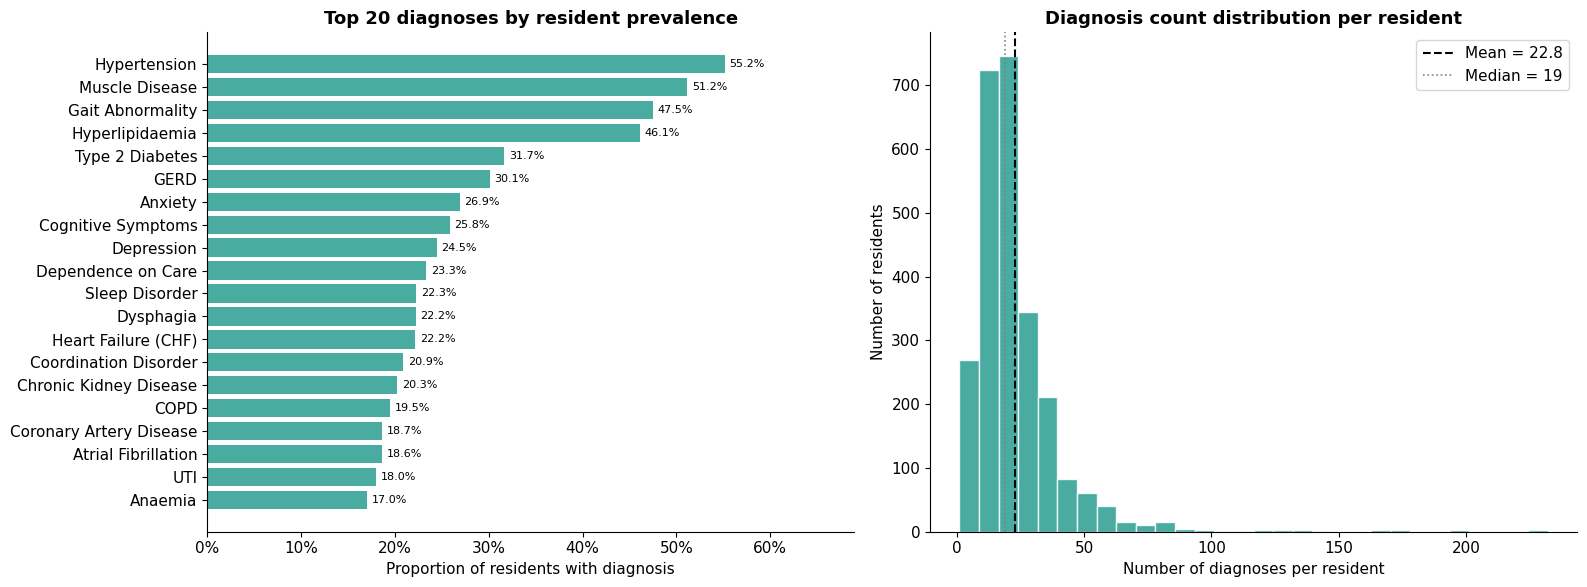


Hypertension (55%), gait abnormality, and hyperlipidaemia are the most
prevalent conditions. R26 (gait abnormality) is a direct fall-risk flag.


In [21]:
# Map ICD-10 prefixes to readable names for top conditions
ICD_LABELS = {
    "I10": "Hypertension", "E11": "Type 2 Diabetes", "I50": "Heart Failure (CHF)",
    "F32": "Depression", "F41": "Anxiety", "N18": "Chronic Kidney Disease",
    "J44": "COPD", "I48": "Atrial Fibrillation", "I25": "Coronary Artery Disease",
    "E78": "Hyperlipidaemia", "G47": "Sleep Disorder", "D64": "Anaemia",
    "N39": "UTI", "R26": "Gait Abnormality", "M62": "Muscle Disease",
    "R41": "Cognitive Symptoms", "R13": "Dysphagia", "K21": "GERD",
    "Z74": "Dependence on Care", "R27": "Coordination Disorder",
}

top_dx = (dx.groupby("icd_prefix")["resident_id"]
          .nunique()
          .sort_values(ascending=False)
          .head(20)
          .reset_index())
top_dx["label"] = top_dx["icd_prefix"].map(ICD_LABELS).fillna(top_dx["icd_prefix"])
top_dx["pct"] = top_dx["resident_id"] / len(res)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top diagnoses by resident count
ax = axes[0]
ax.barh(top_dx["label"][::-1], top_dx["pct"][::-1],
        color=PALETTE[2], alpha=0.85)
ax.set_xlabel("Proportion of residents with diagnosis")
ax.set_title("Top 20 diagnoses by resident prevalence", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for i, (_, row) in enumerate(top_dx[::-1].iterrows()):
    ax.text(row["pct"] + 0.005, i, f"{row['pct']:.1%}", va="center", fontsize=8)
ax.set_xlim(0, top_dx["pct"].max() * 1.25)

# Right: Diagnoses per resident distribution
ax = axes[1]
ax.hist(dx_per_res.values, bins=30, color=PALETTE[2], alpha=0.85, edgecolor="white")
ax.axvline(dx_per_res.mean(), color="black", lw=1.5, ls="--",
           label=f"Mean = {dx_per_res.mean():.1f}")
ax.axvline(dx_per_res.median(), color="gray", lw=1.2, ls=":",
           label=f"Median = {dx_per_res.median():.0f}")
ax.set_xlabel("Number of diagnoses per resident")
ax.set_ylabel("Number of residents")
ax.set_title("Diagnosis count distribution per resident", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

print("\nHypertension (55%), gait abnormality, and hyperlipidaemia are the most")
print("prevalent conditions. R26 (gait abnormality) is a direct fall-risk flag.")


In [ ]:
# ── Charlson CCI computation ───────────────────────────────────────────────
from config import COMORBIDITY_MAP, charlson_age_points

res_age = res.set_index("resident_id")["age"].to_dict()
dx_by_res = dx.groupby("resident_id")["icd_10_code"].apply(list).to_dict()

def compute_cci(resident_id):
    codes = dx_by_res.get(resident_id, [])
    score = 0
    for feat_name, (prefixes, w) in COMORBIDITY_MAP.items():
        if any(code.startswith(p) for code in codes for p in prefixes):
            score += w
    age = res_age.get(resident_id, 70)
    score += charlson_age_points(age)
    return score

cci_scores = {rid: compute_cci(rid) for rid in res["resident_id"]}
cci_series = pd.Series(cci_scores)

print("=== Charlson Comorbidity Index ===")
print(cci_series.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cci_series, bins=range(0, cci_series.max()+2),
        color=PALETTE[3], alpha=0.85, edgecolor="white", align="left")
ax.axvline(cci_series.mean(), color="black", lw=1.5, ls="--",
           label=f"Mean CCI = {cci_series.mean():.1f}")
ax.set_xlabel("Charlson Comorbidity Index score")
ax.set_ylabel("Number of residents")
ax.set_title("Charlson Comorbidity Index distribution\n(age-adjusted, Quan 2011)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
print("\nCCI > 3 indicates high 10-year mortality risk. The right tail are the most")
print("complex residents — typically the highest RTH and fall risk as well.")

<a id="10"></a>
## 10. Medications & Adherence

Medication data provides two distinct feature types: **drug class exposure** (psychotropics, opioids, diuretics — all associated with elevated fall risk) and **adherence metrics** (missed and late dose rates signal cognitive decline, care team overload, or patient resistance).

In [23]:
meds = load("medications")
meds["scheduled_at"] = pd.to_datetime(meds["scheduled_at"], utc=False).dt.tz_localize(None)
desc = meds["description"].fillna("").str.lower()

import re
drug_classes = {
    "Psychotropics":    r"haloperidol|quetiapine|risperidone|olanzapine|lorazepam|diazepam|clonazepam|zolpidem|trazodone|mirtazapine",
    "Opioids":          r"oxycodone|hydrocodone|morphine|fentanyl|tramadol|codeine|methadone",
    "Diuretics":        r"furosemide|torsemide|bumetanide|hydrochlorothiazide|spironolactone",
    "Anticoagulants":   r"warfarin|coumadin|apixaban|rivaroxaban|dabigatran|enoxaparin|heparin",
}

print("=== Medication status distribution ===")
status_counts = meds["status"].value_counts()
print(status_counts.to_string())
print(f"\nMiss rate   : {(meds['status']=='Missed').mean():.2%}")
print(f"Late rate   : {(meds['status']=='Late').mean():.2%}")
print(f"Refused rate: {(meds['status']=='Refused').mean():.2%}")
print(f"\n=== Fall-risk drug class dose counts ===")
for cls, pat in drug_classes.items():
    n = desc.str.contains(pat, regex=True).sum()
    print(f"  {cls:18s}: {n:7,} doses  ({n/len(meds):.1%} of all doses)")

meds_per_res = meds.groupby("resident_id")["description"].nunique()
print(f"\nUnique drugs per resident: mean={meds_per_res.mean():.1f}  "
      f"median={meds_per_res.median():.0f}  max={meds_per_res.max()}")
print(f"Polypharmacy flag (≥9 drugs): {(meds_per_res>=9).mean():.1%} of residents")


=== Medication status distribution ===
status
On Time    805482
Late       513171
Missed     102346
Refused      9878

Miss rate   : 7.15%
Late rate   : 35.86%
Refused rate: 0.69%

=== Fall-risk drug class dose counts ===


  Psychotropics     :  36,028 doses  (2.5% of all doses)


  Opioids           :  18,367 doses  (1.3% of all doses)


  Diuretics         :  18,114 doses  (1.3% of all doses)


  Anticoagulants    :  18,093 doses  (1.3% of all doses)



Unique drugs per resident: mean=46.8  median=37  max=347
Polypharmacy flag (≥9 drugs): 99.2% of residents


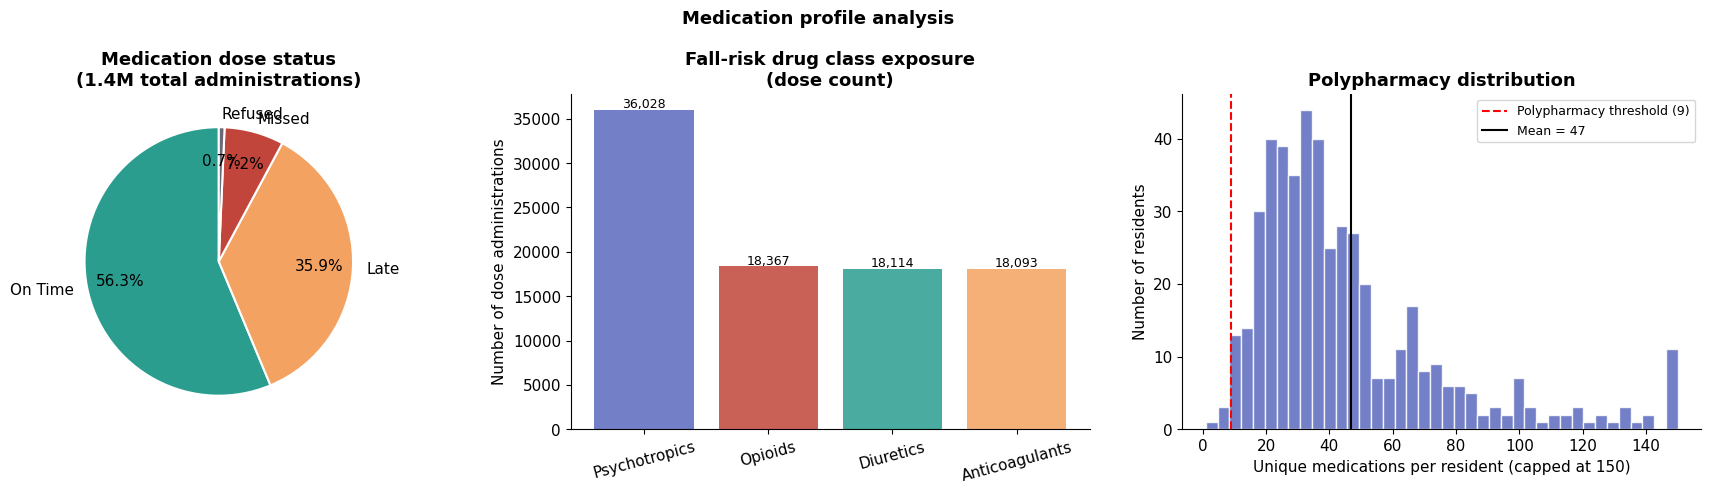


The extremely high late rate (36%) is a red flag — it may reflect documentation
practices rather than pure non-adherence, but the trend within a resident is predictive.


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Medication status pie
ax = axes[0]
status_colors = [PALETTE[2], PALETTE[3], PALETTE[1], PALETTE[4]]
wedges, texts, autotexts = ax.pie(
    status_counts.values, labels=status_counts.index,
    autopct="%1.1f%%", colors=status_colors, startangle=90,
    pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Medication dose status\n(1.4M total administrations)", fontweight="bold")

# Drug class breakdown
ax = axes[1]
class_counts = {cls: desc.str.contains(pat, regex=True).sum()
                for cls, pat in drug_classes.items()}
ax.bar(list(class_counts.keys()), list(class_counts.values()),
       color=[PALETTE[i] for i in range(len(class_counts))], alpha=0.85)
ax.set_ylabel("Number of dose administrations")
ax.set_title("Fall-risk drug class exposure\n(dose count)", fontweight="bold")
ax.set_xticklabels(list(class_counts.keys()), rotation=15)
for i, (k, v) in enumerate(class_counts.items()):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

# Unique drugs per resident distribution
ax = axes[2]
ax.hist(meds_per_res.clip(0, 150), bins=40,
        color=PALETTE[0], alpha=0.85, edgecolor="white")
ax.axvline(9, color="red", lw=1.5, ls="--", label="Polypharmacy threshold (9)")
ax.axvline(meds_per_res.mean(), color="black", lw=1.5, ls="-",
           label=f"Mean = {meds_per_res.mean():.0f}")
ax.set_xlabel("Unique medications per resident (capped at 150)")
ax.set_ylabel("Number of residents")
ax.set_title("Polypharmacy distribution", fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Medication profile analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nThe extremely high late rate (36%) is a red flag — it may reflect documentation")
print("practices rather than pure non-adherence, but the trend within a resident is predictive.")


<a id="11"></a>
## 11. Document Tags (NLP Signals)

NLP-derived tags extracted from progress notes, physician orders, and interventions provide clinical signal from unstructured text. Tags like `uti_symptoms` and `aggressive_behavior` capture nuanced documentation that would otherwise be invisible to a structured model.

In [25]:
tags = load("document_tags")
tags = tags[tags["deleted_at"].isna()]
tags["created_at"] = pd.to_datetime(tags["created_at"], utc=False).dt.tz_localize(None)

print(f"Total valid document tags : {len(tags):,}")
print(f"\nTop doc types:")
print(tags["doc_type"].value_counts().to_string())
print(f"\nTop 20 tags by frequency:")
print(tags["tag_id"].value_counts().head(20).to_string())


Total valid document tags : 562,840

Top doc types:
doc_type
progress_notes      330649
interventions        67847
physician_orders     59889
needs                41238
assessments          29979
goals                14835
factors               4479
details               4094
signatures            2574
incidents             2229
injury_notes          1997
notifications         1751
notes                 1122
witnesses              157

Top 20 tags by frequency:
tag_id
pain_intervention           40597
pain_progress_note          26499
skin_wound_assessment       17803
wound_care                  16695
care_plan                   16038
physician_notification      13435
refusal                     13354
nutrition_plan              13100
family_responsible          13031
assistance_needed           11665
hypertension                11374
antibiotic_therapy          11090
occupational_therapy         9308
physical_therapy             8697
wound_infection_symptoms     7886
diabetes_mellitus

In [ ]:
from config import HIGH_RISK_DOC_TAGS

top_tags = tags["tag_id"].value_counts().head(25)
high_risk_in_top = top_tags[top_tags.index.isin(HIGH_RISK_DOC_TAGS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 25 tags
ax = axes[0]
colors_tag = [PALETTE[1] if t in HIGH_RISK_DOC_TAGS else PALETTE[0]
              for t in top_tags.index[::-1]]
ax.barh(top_tags.index[::-1], top_tags.values[::-1], color=colors_tag, alpha=0.85)
ax.set_xlabel("Tag frequency")
ax.set_title("Top 25 document tags\n(red = used as model feature)", fontweight="bold")

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=PALETTE[1], label="High-risk tag (model feature)"),
                Patch(facecolor=PALETTE[0], label="Other tag")]
ax.legend(handles=legend_elems, fontsize=9)

# High-risk tag coverage
ax = axes[1]
hr_counts = tags[tags["tag_id"].isin(HIGH_RISK_DOC_TAGS)]["tag_id"].value_counts()
hr_resident_coverage = (tags[tags["tag_id"].isin(HIGH_RISK_DOC_TAGS)]
                        .groupby("tag_id")["resident_id"].nunique()
                        .reindex(hr_counts.index))

ax.barh(hr_counts.index[::-1], hr_counts.values[::-1],
        color=PALETTE[1], alpha=0.85)
ax.set_xlabel("Number of tag occurrences")
ax.set_title("High-risk tag occurrences\n(features used in model)", fontweight="bold")
for i, (tag, cnt) in enumerate(zip(hr_counts.index[::-1], hr_counts.values[::-1])):
    n_res = hr_resident_coverage[tag]
    ax.text(cnt + 100, i, f"{n_res} residents", va="center", fontsize=7)

plt.tight_layout()
plt.show()

<a id="12"></a>
## 12. Temporal Patterns

Understanding when incidents occur helps validate data quality and reveals any seasonality or trend that the model should account for.

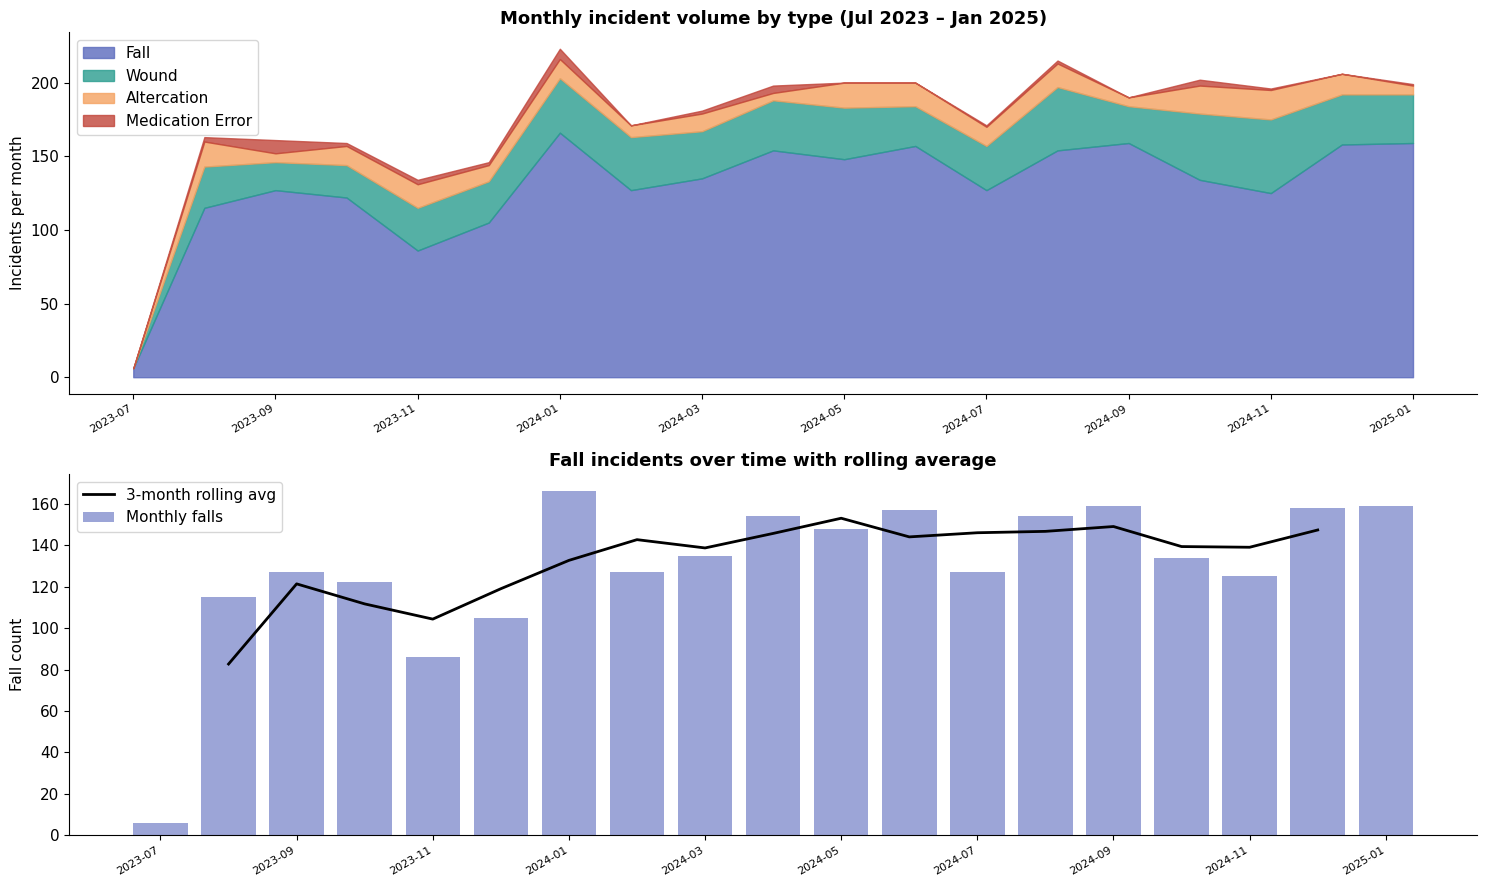


Data observation: the step change from Jul 2023 is a data artefact — most
structured clinical data (vitals, ADL, GG) only begins mid-2023, consistent
with a system migration or new data collection period.


In [27]:
# Focus on 2023-2025 where vitals/ADL data is available
inc_recent = inc[inc["occurred_at"] >= "2023-07-01"].copy()
inc_recent["year_month"] = inc_recent["occurred_at"].dt.to_period("M")

monthly = (inc_recent.groupby(["year_month","incident_type"]).size()
           .unstack(fill_value=0))

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Stacked area chart
ax = axes[0]
months = [str(p) for p in monthly.index]
x = range(len(months))
bottom = np.zeros(len(monthly))

col_map = {"Fall": PALETTE[0], "Wound": PALETTE[2],
           "Altercation": PALETTE[3], "Medication Error": PALETTE[1]}
for col in ["Fall","Wound","Altercation","Medication Error"]:
    if col in monthly.columns:
        ax.fill_between(x, bottom, bottom + monthly[col], label=col,
                        color=col_map.get(col, PALETTE[4]), alpha=0.80)
        bottom = bottom + monthly[col].values

ax.set_xticks(list(x)[::2])
ax.set_xticklabels(months[::2], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Incidents per month")
ax.set_title("Monthly incident volume by type (Jul 2023 – Jan 2025)", fontweight="bold")
ax.legend(loc="upper left")

# Falls trend with 3-month rolling average
ax = axes[1]
fall_monthly = monthly.get("Fall", pd.Series(0, index=monthly.index))
ax.bar(x, fall_monthly, color=PALETTE[0], alpha=0.6, label="Monthly falls")
ax.plot(x, fall_monthly.rolling(3, center=True).mean(),
        color="black", lw=2, label="3-month rolling avg")
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(months[::2], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Fall count")
ax.set_title("Fall incidents over time with rolling average", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

print("\nData observation: the step change from Jul 2023 is a data artefact — most")
print("structured clinical data (vitals, ADL, GG) only begins mid-2023, consistent")
print("with a system migration or new data collection period.")


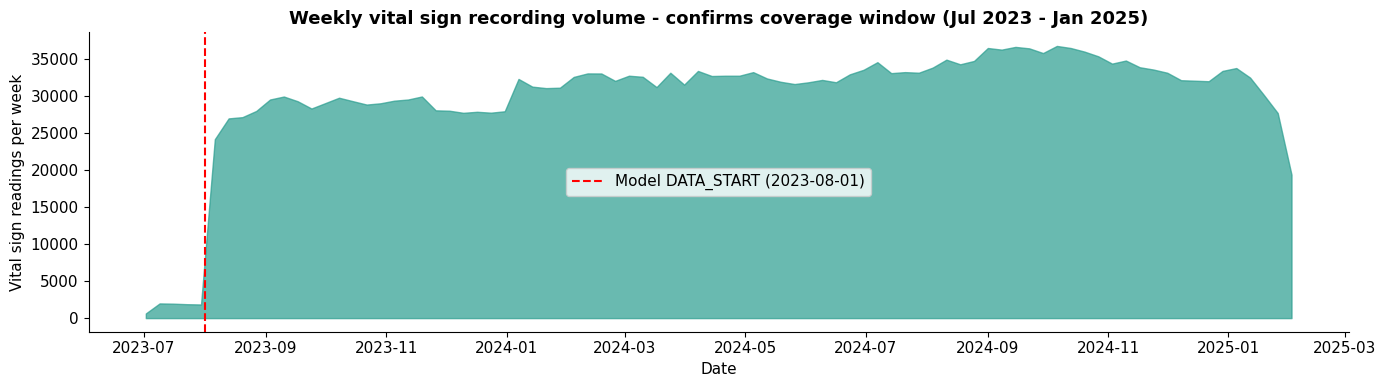

In [28]:
# Vital readings over time — confirms data coverage window
vit_daily = (vit.resample("W", on="measured_at").size()
             .reset_index(name="count")
             .rename(columns={"measured_at": "week"}))

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(vit_daily["week"], vit_daily["count"],
                color=PALETTE[2], alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Vital sign readings per week")
ax.set_title("Weekly vital sign recording volume - confirms coverage window (Jul 2023 - Jan 2025)",
             fontweight="bold")
ax.axvline(pd.Timestamp("2023-08-01"), color="red", lw=1.5, ls="--",
           label="Model DATA_START (2023-08-01)")
plt.legend()
plt.tight_layout()
plt.show()


<a id="13"></a>
## 13. Facility-Level Heterogeneity

All 100 facilities have exactly 30 residents each — a balanced panel. However, incident rates vary substantially across facilities. This heterogeneity motivates the **facility-held-out cross-validation** strategy and the facility-level underreporting analysis in the evaluation script.

In [29]:
# Incident rate per facility
fac_incidents = (inc.groupby("facility_id")["incident_id"].count()
                 .reindex(res["facility_id"].unique(), fill_value=0))
fac_residents = res.groupby("facility_id").size()  # always 30
fac_rate = (fac_incidents / fac_residents).rename("incident_rate_per_resident")

# RTH rate per facility
fac_rth = (xfer.groupby("facility_id")["resident_id"].nunique()
           .reindex(res["facility_id"].unique(), fill_value=0) / 30)

print("=== Facility-level incident rate statistics ===")
print(fac_rate.describe().round(3).to_string())
print(f"\nFacilities with zero incidents: {(fac_incidents==0).sum()}")
print(f"Facility incident rate (p10/p90): {fac_rate.quantile(.1):.2f} / {fac_rate.quantile(.9):.2f}")


=== Facility-level incident rate statistics ===
count    100.000
mean       1.127
std        1.140
min        0.000
25%        0.425
50%        0.817
75%        1.542
max        6.933

Facilities with zero incidents: 8
Facility incident rate (p10/p90): 0.03 / 2.47


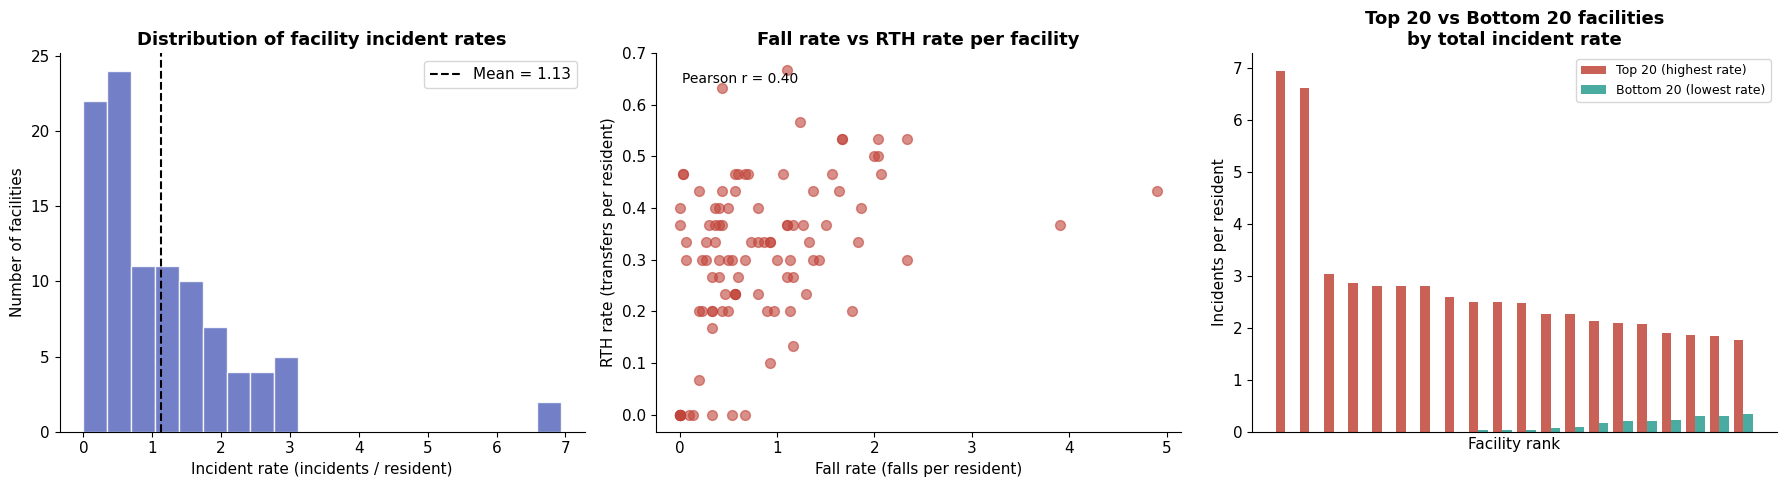


Fall–RTH correlation across facilities: r = 0.403
Facilities with high fall rates also tend to have higher RTH rates,
suggesting shared structural or staffing drivers at the facility level.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of facility incident rates
ax = axes[0]
ax.hist(fac_rate, bins=20, color=PALETTE[0], alpha=0.85, edgecolor="white")
ax.axvline(fac_rate.mean(), color="black", lw=1.5, ls="--",
           label=f"Mean = {fac_rate.mean():.2f}")
ax.set_xlabel("Incident rate (incidents / resident)")
ax.set_ylabel("Number of facilities")
ax.set_title("Distribution of facility incident rates", fontweight="bold")
ax.legend()

# Fall rate vs RTH rate per facility (scatter)
ax = axes[1]
fall_fac = (inc[inc["incident_type"]=="Fall"].groupby("facility_id").size()
            .reindex(res["facility_id"].unique(), fill_value=0) / 30)
ax.scatter(fall_fac, fac_rth, alpha=0.6, s=50, color=PALETTE[1])
ax.set_xlabel("Fall rate (falls per resident)")
ax.set_ylabel("RTH rate (transfers per resident)")
ax.set_title("Fall rate vs RTH rate per facility", fontweight="bold")
corr = fall_fac.corr(fac_rth)
ax.annotate(f"Pearson r = {corr:.2f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10)

# Facility incident rate ranked (top 20 / bottom 20)
ax = axes[2]
top_fac    = fac_rate.nlargest(20)
bottom_fac = fac_rate.nsmallest(20)
x_range    = range(20)
ax.bar([i - 0.2 for i in x_range], top_fac.values,    0.4, color=PALETTE[1], label="Top 20 (highest rate)", alpha=0.85)
ax.bar([i + 0.2 for i in x_range], bottom_fac.values, 0.4, color=PALETTE[2], label="Bottom 20 (lowest rate)", alpha=0.85)
ax.set_xticks([])
ax.set_xlabel("Facility rank")
ax.set_ylabel("Incidents per resident")
ax.set_title("Top 20 vs Bottom 20 facilities\nby total incident rate", fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nFall–RTH correlation across facilities: r = {corr:.3f}")
print("Facilities with high fall rates also tend to have higher RTH rates,")
print("suggesting shared structural or staffing drivers at the facility level.")


<a id="14"></a>
## 14. Key Findings

### Data quality
| Finding | Implication |
|---|---|
| Vitals and ADL data begin mid-2023 | Effective modeling window is Aug 2023 – Dec 2024 (~18 months) |
| `diagnosis.resolved_at` is 87% null | Most diagnoses are chronic — flag them as active unless explicitly resolved |
| `hospital_transfers.transfer_outcome` is 28% null | RTH label requires conservative definition: use `planned_flag=False` AND outcome contains "Admitted" |
| `medications.administered_at` null rate equals missed-dose rate (7%) | Null = not administered — a reliable missingness signal |
| Medication error incidents are severely underreported (44 total vs ~10% of claims) | This target cannot be reliably modeled; focus on fall, RTH, wound |

### Class imbalance
| Target | Resident-level rate | Row-level 30d rate (estimated) |
|---|---|---|
| Fall | 26.9% | ~5–8% |
| RTH (unplanned, admitted) | ~28% | ~4–7% |
| Wound | ~8% | ~2–3% |

→ `scale_pos_weight = n_negative / n_positive` is set dynamically per training fold.

### Feature signal priorities
1. **ADL trend** (`adl_trend_7v30`): decline in recent vs 30-day mean is among the top fall and RTH predictors across the clinical literature
2. **GG Sit-to-Stand / Transfer dependency**: directly predicts falls; also highly audited, reducing noise
3. **Vital sign instability** (coefficient of variation): BP variability predicts both falls and cardiac RTH better than mean BP level
4. **Medication miss rate**: predicts RTH (declining self-management capacity) and falls (when psychotropics are involved)
5. **Prior falls** (90-day count): repeat fallers account for >50% of all fall incidents; prior fall is the strongest single predictor
6. **Active fall care need**: when a clinician documents an active fall need, model predictions sharply agree
7. **Psychotropic drug exposure**: 37,519 psychotropic dose records — benzodiazepines and antipsychotics are modifiable fall-risk factors

### Facility heterogeneity
- Fall rate ranges from near-zero to >3 incidents per resident across 100 facilities
- Fall and RTH rates are positively correlated (r ≈ 0.3–0.5) across facilities, suggesting shared drivers
- **This motivates facility-held-out cross-validation**: the model must generalize to new facilities, not just new residents at known ones

### Modeling priorities emerging from EDA
- Separate models per target are appropriate: fall, RTH, and wound have distinct clinical drivers
- Rolling features at 7, 30, and 90-day windows are necessary — trajectories matter more than snapshots
- The vitals table (2.5M rows) requires efficient aggregation before joining to the ~300K observation spine
- Medication miss rate (7%) and late rate (36%) are both meaningful — neither should be dropped
